# Final results

This brings together every model already trained, the M0 to M4 ladder, D0, and the TF-IDF reference, into one place. Nothing is retrained or retuned here. Every number below comes straight from the saved results files.

## Load results

In [1]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import LABELS
from src.evaluation import calculate_deltas, format_delta, seed_statistics
from src.results import generate_comparison_table, validate_runs_csv

is_valid, errors = validate_runs_csv("../results/runs.csv", check_seed_completeness=True)
print("runs.csv valid (all seed counts, incl. D0 x3):", is_valid, errors)

df = pd.read_csv("../results/runs.csv")
tfidf = json.load(open("../results/tfidf_reference.json"))
print(f"rows: {len(df)}, experiments: {sorted(df['experiment'].unique())}")

runs.csv valid (all seed counts, incl. D0 x3): True []
rows: 10, experiments: ['D0', 'M0', 'M1', 'M2', 'M3', 'M4']


This checks that every model was run the planned number of times, three seeds each for M0 and D0, one seed each for M1 to M4. That budget was fixed before training started.

## Final comparison

In [2]:
table = generate_comparison_table()
table

,Model,Configuration,Macro-F1,Accuracy,Δ vs Previous,Δ vs M0,Best Epoch,Time,Parameters,Interpretation


This table is generated automatically from the results files, not typed by hand. TF-IDF is not included as a row, since it is a separate reference point, not one of the six official models.

In [3]:
print(f"TF-IDF reference (auxiliary, not part of the ladder): Macro-F1 = {tfidf['macro_f1']:.4f}")

TF-IDF reference (auxiliary, not part of the ladder): Macro-F1 = 0.8707


## Deltas (full precision)

In [4]:
m0_mean = seed_statistics(df[df["experiment"] == "M0"]["macro_f1"].values)["mean"]
print(f"canonical M0 mean (full precision): {m0_mean!r}")

order = ["M0", "M1", "M2", "M3", "M4", "D0"]
f1_by_exp = {}
for exp in order:
    sub = df[df["experiment"] == exp]
    f1_by_exp[exp] = seed_statistics(sub["macro_f1"].values)["mean"]

print(f"{'rung':<6}{'incremental':>18}{'cumulative (vs M0)':>22}")
prev = None
for exp in order:
    f1 = f1_by_exp[exp]
    inc = calculate_deltas(current_f1=f1, previous_f1=prev)["delta_vs_previous"]
    cum = calculate_deltas(current_f1=f1, baseline_m0_f1=m0_mean)["delta_vs_m0"] if exp != "M0" else None
    inc_str = format_delta(inc) if inc is not None else "—"
    cum_str = format_delta(cum) if cum is not None else "—"
    print(f"{exp:<6}{inc_str:>18}{cum_str:>22}   (exact inc={inc!r}, cum={cum!r})")
    prev = f1

canonical M0 mean (full precision): 0.850833078773998
rung         incremental    cumulative (vs M0)
M0                     —                     —   (exact inc=None, cum=None)
M1               -0.0023               -0.0023   (exact inc=-0.002317621684802651, cum=-0.002317621684802651)
M2               +0.0033               +0.0010   (exact inc=0.003282040681856002, cum=0.0009644189970533512)
M3               +0.0139               +0.0148   (exact inc=0.013870261991500099, cum=0.01483468098855345)
M4               +0.0054               +0.0202   (exact inc=0.005355986585742878, cum=0.020190667574296328)
D0               +0.0048               +0.0250   (exact inc=0.00482950383535119, cum=0.025020171409647518)


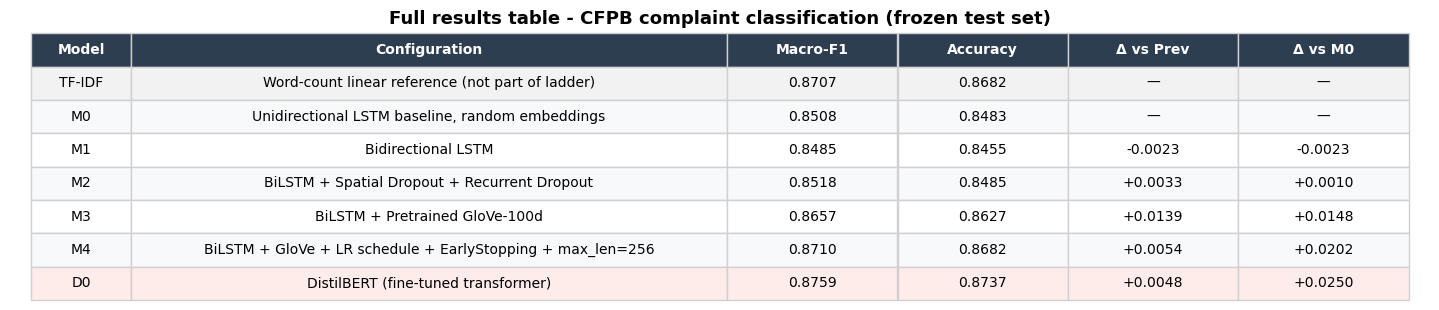

In [5]:
config_desc = {
    "M0": "Unidirectional LSTM baseline, random embeddings",
    "M1": "Bidirectional LSTM",
    "M2": "BiLSTM + Spatial Dropout + Recurrent Dropout",
    "M3": "BiLSTM + Pretrained GloVe-100d",
    "M4": "BiLSTM + GloVe + LR schedule + EarlyStopping + max_len=256",
    "D0": "DistilBERT (fine-tuned transformer)",
}
rows_tbl = [("TF-IDF", "Word-count linear reference (not part of ladder)", tfidf["macro_f1"], tfidf["accuracy"], "\u2014", "\u2014")]
prev_f1 = None
for exp in order:
    macro = f1_by_exp[exp]
    acc = df[df["experiment"] == exp]["accuracy"].mean()
    d_prev = "\u2014" if prev_f1 is None else f"{macro - prev_f1:+.4f}"
    d_m0 = "\u2014" if exp == "M0" else f"{macro - f1_by_exp['M0']:+.4f}"
    rows_tbl.append((exp, config_desc[exp], macro, acc, d_prev, d_m0))
    prev_f1 = macro

fig, ax = plt.subplots(figsize=(14.5, 3.2))
ax.axis("off")
cell_text = [[r[0], r[1], f"{r[2]:.4f}", f"{r[3]:.4f}", r[4], r[5]] for r in rows_tbl]
col_labels = ["Model", "Configuration", "Macro-F1", "Accuracy", "\u0394 vs Prev", "\u0394 vs M0"]
tbl = ax.table(cellText=cell_text, colLabels=col_labels, loc="center", cellLoc="center",
               colWidths=[0.07, 0.42, 0.12, 0.12, 0.12, 0.12])
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 2.0)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#d0d0d0")
    if row == 0:
        cell.set_facecolor("#2c3e50"); cell.get_text().set_color("white"); cell.get_text().set_fontweight("bold")
    else:
        name = rows_tbl[row - 1][0]
        if name == "D0":
            cell.set_facecolor("#fdecea")
        elif name == "TF-IDF":
            cell.set_facecolor("#f2f2f2")
        elif row % 2 == 0:
            cell.set_facecolor("#f8f9fb")
ax.set_title("Full results table - CFPB complaint classification (frozen test set)", fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
fig.savefig("../assets/results_table.png", dpi=150, bbox_inches="tight")
plt.show()


1. D0 is not a seventh model in the ladder. It is a separate comparison, so its delta is measured against M4, the best recurrent model, since that is the only sensible point to compare it to.
2. All the cumulative deltas below use the exact, unrounded M0 average rather than the rounded 0.8508 shown in the table, to avoid small rounding errors.

## Per-class results

In [6]:
def per_class(path):
    return json.load(open(path))["per_class"]

m0_seeds = [per_class(f"../results/m0/seed{s}/test_metrics.json") for s in [42, 123, 456]]
d0_seeds = [per_class(f"../results/d0/seed{s}/test_metrics.json") for s in [42, 123, 456]]
m1 = per_class("../results/m1/seed42/test_metrics.json")
m2 = per_class("../results/m2/seed42/test_metrics.json")
m3 = per_class("../results/m3/seed42/test_metrics.json")
m4 = per_class("../results/m4/seed42/test_metrics.json")

rows = []
for lbl in LABELS:
    rows.append({
        "class": lbl,
        "M0": np.mean([s[lbl]["f1"] for s in m0_seeds]),
        "M1": m1[lbl]["f1"], "M2": m2[lbl]["f1"], "M3": m3[lbl]["f1"], "M4": m4[lbl]["f1"],
        "D0": np.mean([s[lbl]["f1"] for s in d0_seeds]),
    })
per_class_df = pd.DataFrame(rows).set_index("class")
per_class_df.round(4)

,M0,M1,M2,M3,M4,D0
class,,,,,,
Checking or savings account,0.7650,0.7651,0.7676,0.7816,0.7862,0.7961
Credit card,0.8367,0.8364,0.8307,0.8490,0.8574,0.8657
Debt collection,0.9053,0.9108,0.9117,0.9203,0.9269,0.9235
"Money transfer, virtual currency, or money service",0.7889,0.7715,0.7893,0.8081,0.8144,0.8216
Student loan,0.9582,0.9587,0.9597,0.9693,0.9703,0.9724


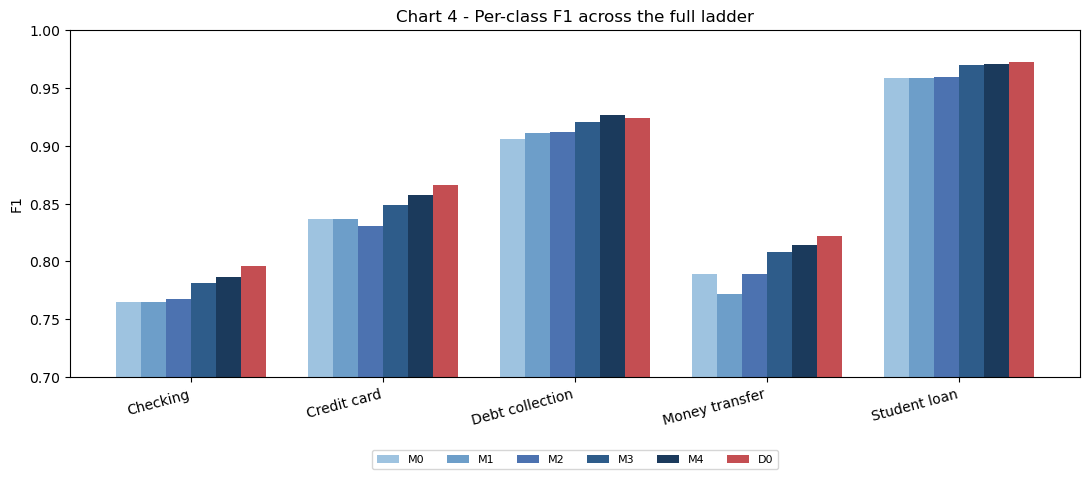

In [7]:
class_labels_short = [l.split(",")[0].split(" or ")[0] for l in LABELS]
model_order = ["M0", "M1", "M2", "M3", "M4", "D0"]
model_colors = ["#9EC3E0", "#6D9EC9", "#4C72B0", "#2E5C8A", "#1B3A5C", "#C44E52"]
x = np.arange(len(class_labels_short))
width = 0.13
fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(model_order):
    vals = per_class_df[m].values
    ax.bar(x + (i - 2.5) * width, vals, width, label=m, color=model_colors[i])
ax.set_xticks(x)
ax.set_xticklabels(class_labels_short, rotation=15, ha="right")
ax.set_ylabel("F1")
ax.set_ylim(0.7, 1.0)
ax.set_title("Chart 4 - Per-class F1 across the full ladder")
ax.legend(ncol=6, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.28))
plt.tight_layout()
fig.savefig("../assets/per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()


1. Every class gets better going from M0 to D0.
2. Student loan is the easiest class throughout, going from 0.958 to 0.972. Checking or savings and Money transfer stay the two hardest at every stage, since these two categories share a lot of vocabulary, both being account level payment issues.
3. GloVe (M3) lifts every class at once, not just one. A broad, general improvement.
4. D0 beats M4 in four of five classes. The one exception is Debt collection, where M4 edges ahead slightly, 0.9269 versus 0.9235. That is not a sign D0 is weak, just one class where the recurrent model happens to do a bit better.

## Compute cost

In [8]:
cost_rows = []
for exp in order:
    sub = df[df["experiment"] == exp]
    f1 = f1_by_exp[exp]
    time_stats = seed_statistics(sub["train_time"].values)
    time_str = f"{time_stats['mean']:.0f}s" if time_stats["std"] is None else f"{time_stats['mean']:.0f}s ± {time_stats['std']:.0f}s"
    cost_rows.append({
        "Model": exp, "Macro-F1": f"{f1:.4f}", "Training Time": time_str,
        "Parameters": f"{int(sub['parameter_count'].iloc[0]):,}",
    })
pd.DataFrame(cost_rows)

,Model,Macro-F1,Training Time,Parameters
0,M0,0.8508,166s ± 11s,"2,117,893"
1,M1,0.8485,274s,"2,235,781"
2,M2,0.8518,6790s,"2,235,781"
3,M3,0.8657,6793s,"2,235,781"
4,M4,0.8710,10941s,"2,235,781"
5,D0,0.8759,5404s ± 21s,"66,957,317"


1. M2 through M4 take much longer to train, mainly because recurrent dropout disables a GPU speed optimization for LSTMs, not because they have more parameters. Parameter count stays flat at about 2.2 million from M1 onward.
2. M4 is about 67 times slower than M0 despite having almost the same parameter count, for that same reason plus the longer 256 word input.
3. D0 has 30 times more parameters than M4 but actually trains faster per run, about 90 minutes versus 182 minutes. It is not a recurrent model, so it never hits that slowdown.

## Training dynamics

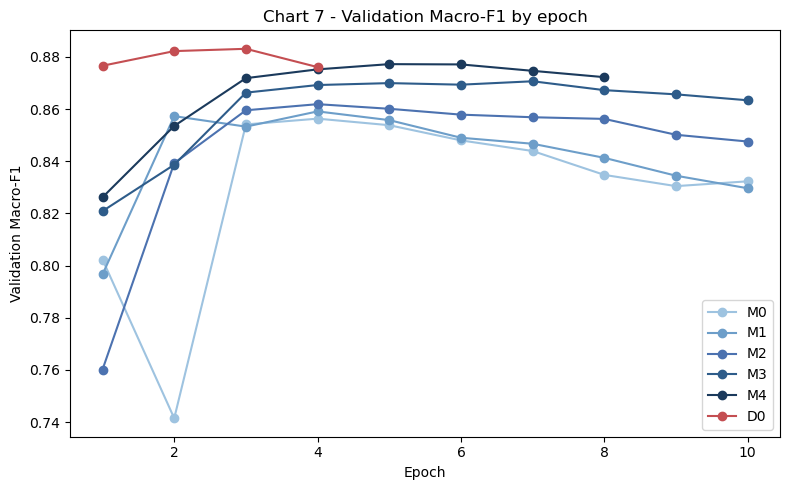

In [9]:
history = {exp: json.load(open(f"../results/{exp.lower()}/seed42/history.json")) for exp in model_order}
fig, ax = plt.subplots(figsize=(8, 5))
for i, exp in enumerate(model_order):
    vals = history[exp]["val_macro_f1"]
    ax.plot(range(1, len(vals) + 1), vals, marker="o", color=model_colors[i], label=exp)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Macro-F1")
ax.set_title("Chart 7 - Validation Macro-F1 by epoch")
ax.legend()
plt.tight_layout()
fig.savefig("../assets/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


1. D0 reaches 0.883 validation Macro F1 in 4 epochs. M4 needs 8 epochs to reach 0.877 and never gets past that.
2. Pretraining is doing the work here, not depth or width. D0 has 30 times the parameters of M4 but converges in half the epochs.
3. M0 through M3 flatten out slower and lower than M4. That fits with recurrent dropout and the longer context window giving M4 real headroom, not just extra training time.

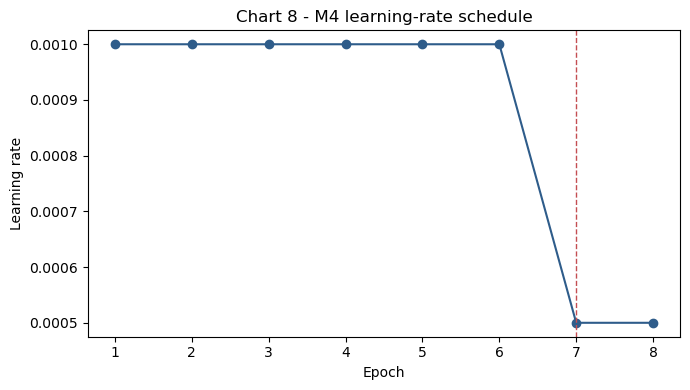

In [10]:
lr_hist = json.load(open("../results/m4/seed42/lr_history.json"))
lr_vals = lr_hist["lr_by_epoch"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(lr_vals) + 1), lr_vals, marker="o", color="#2E5C8A")
for r in lr_hist["reductions"]:
    ax.axvline(r["epoch"], color="#C44E52", linestyle="--", linewidth=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("Chart 8 - M4 learning-rate schedule")
plt.tight_layout()
plt.show()


The only learning rate drop, at epoch 7 from 0.001 to 0.0005, comes after validation Macro F1 already peaked at epoch 5, 0.8772, and had started falling, 0.8771 then 0.8747. The scheduler reacted to the plateau, it did not cause the peak. Early stopping, not the learning rate drop, is what actually saved M4 from overfitting further.

## TF-IDF context

In [11]:
print(f"TF-IDF  = {tfidf['macro_f1']:.4f}")
print(f"M4      = {f1_by_exp['M4']:.4f}   (M4 - TF-IDF = {f1_by_exp['M4'] - tfidf['macro_f1']:+.4f})")
print(f"D0      = {f1_by_exp['D0']:.4f}   (D0 - TF-IDF = {f1_by_exp['D0'] - tfidf['macro_f1']:+.4f})")

TF-IDF  = 0.8707
M4      = 0.8710   (M4 - TF-IDF = +0.0003)
D0      = 0.8759   (D0 - TF-IDF = +0.0051)


1. TF-IDF performs almost as well as M4. M4 only improves on it by 0.0003, too small to call a real win.
2. There is no clear evidence the best recurrent model actually beats simple word matching.
3. D0 is the one model that clearly beats TF-IDF, by 0.0051. That is the clearest sign that something beyond just matching keywords is helping here.

## Requirement coverage

In [12]:
coverage = pd.DataFrame([
    {"Requirement": "Baseline", "Experiment": "M0", "Status": "Complete"},
    {"Requirement": "Bidirectional LSTM", "Experiment": "M1", "Status": "Complete"},
    {"Requirement": "Stacked layers", "Experiment": "Excluded", "Status": "Documented"},
    {"Requirement": "Dropout", "Experiment": "M2", "Status": "Complete"},
    {"Requirement": "Recurrent dropout", "Experiment": "M2", "Status": "Complete"},
    {"Requirement": "GloVe", "Experiment": "M3", "Status": "Complete"},
    {"Requirement": "LR scheduling", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "Early stopping", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "Class weights", "Experiment": "Excluded", "Status": "Documented"},
    {"Requirement": "Longer max_length", "Experiment": "M4", "Status": "Complete"},
    {"Requirement": "LSTM -> DistilBERT", "Experiment": "D0", "Status": "Complete"},
])
coverage

,Requirement,Experiment,Status
0,Baseline,M0,Complete
1,Bidirectional LSTM,M1,Complete
2,Stacked layers,Excluded,Documented
3,Dropout,M2,Complete
4,Recurrent dropout,M2,Complete
5,GloVe,M3,Complete
6,LR scheduling,M4,Complete
7,Early stopping,M4,Complete
8,Class weights,Excluded,Documented
9,Longer max_length,M4,Complete


In [13]:
applicable = coverage[coverage["Experiment"] != "Excluded"]
excluded_count = (coverage["Experiment"] == "Excluded").sum()
print(f"{len(applicable)}/{len(applicable)} applicable menu items covered "
      f"({excluded_count} exclusions, both documented)")

9/9 applicable menu items covered (2 exclusions, both documented)


## Charts

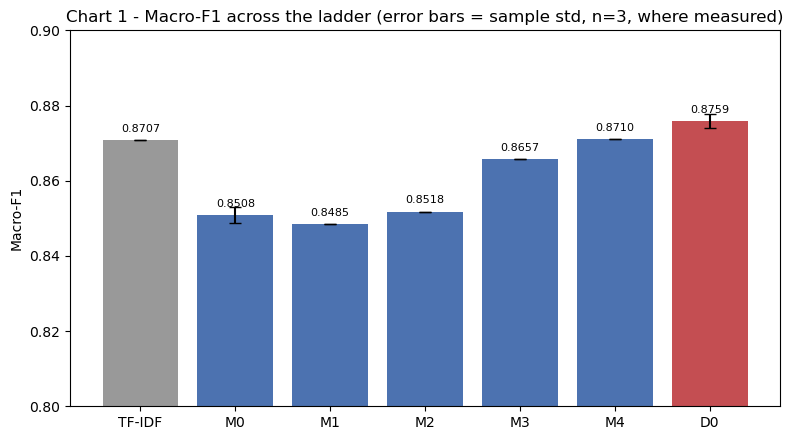

In [14]:
labels_order = ["TF-IDF", "M0", "M1", "M2", "M3", "M4", "D0"]
means = [tfidf["macro_f1"]] + [f1_by_exp[e] for e in order]
stds = [0, f1_by_exp["M0"] and seed_statistics(df[df["experiment"]=="M0"]["macro_f1"].values)["std"], 0, 0, 0, 0,
        seed_statistics(df[df["experiment"]=="D0"]["macro_f1"].values)["std"]]
colors = ["#999999"] + ["#4C72B0"] * 5 + ["#C44E52"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels_order, means, yerr=stds, capsize=4, color=colors)
ax.set_ylabel("Macro-F1")
ax.set_ylim(0.80, 0.90)
ax.set_title("Chart 1 - Macro-F1 across the ladder (error bars = sample std, n=3, where measured)")
for bar, m in zip(bars, means):
    ax.annotate(f"{m:.4f}", (bar.get_x() + bar.get_width() / 2, m), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=8)
plt.tight_layout()
fig.savefig("../assets/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

TF-IDF, in grey, and D0, in red, are colored differently from the M0 to M4 ladder in blue, since neither is officially part of it. Error bars only appear for M0 and D0, since those are the only two run on 3 seeds. M1 to M4 are single runs, so there is no real uncertainty range to show for them.

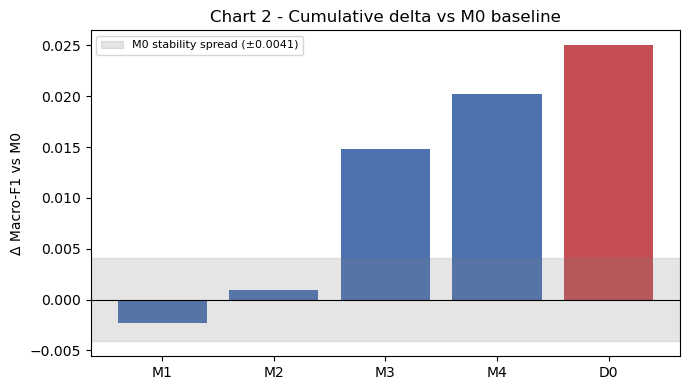

In [15]:
delta_labels = ["M1", "M2", "M3", "M4", "D0"]
delta_vals = [calculate_deltas(current_f1=f1_by_exp[e], baseline_m0_f1=m0_mean)["delta_vs_m0"] for e in delta_labels]

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ["#4C72B0"] * 4 + ["#C44E52"]
ax.bar(delta_labels, delta_vals, color=bar_colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhspan(-0.004125488876295158, 0.004125488876295158, color="grey", alpha=0.2,
           label="M0 stability spread (±0.0041)")
ax.set_ylabel("Δ Macro-F1 vs M0")
ax.set_title("Chart 2 - Cumulative delta vs M0 baseline")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The shaded band shows how much M0's own score wobbled across its 3 seeds. This is the baseline noise level, not a formal statistical test. M1 and M2 fall inside that band, so their improvement cannot be told apart from normal noise. M3, M4, and D0 all sit clearly outside it, which counts as a real improvement.

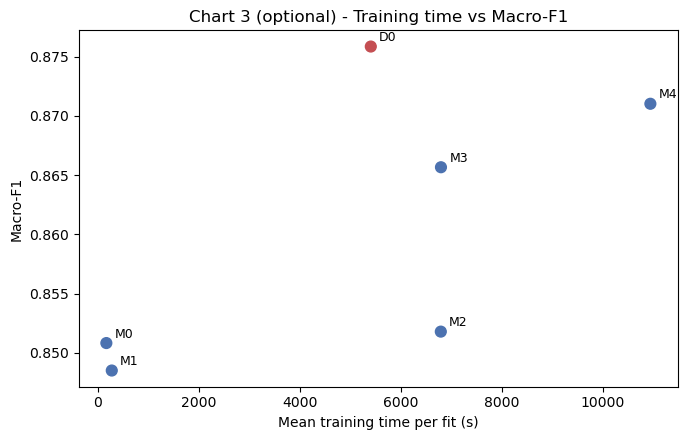

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
times = [seed_statistics(df[df["experiment"] == e]["train_time"].values)["mean"] for e in order]
point_colors = ["#4C72B0"] * 5 + ["#C44E52"]
ax.scatter(times, [f1_by_exp[e] for e in order], color=point_colors, s=60)
for e, t in zip(order, times):
    ax.annotate(e, (t, f1_by_exp[e]), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Mean training time per fit (s)")
ax.set_ylabel("Macro-F1")
ax.set_title("Chart 3 (optional) - Training time vs Macro-F1")
plt.tight_layout()
plt.show()

D0 trains faster than M2 to M4 despite being a much bigger model, since it skips the recurrent dropout slowdown that makes those three expensive. M0 and M1 are cheap but weaker. M3 and M4 cost a lot more compute for a real, if modest, extra gain.

## Final model decision

Best recurrent model: M4, Macro F1 0.8710, the highest of the LSTM ladder and clearly above baseline noise.

Best model overall: D0. All three of D0's seeds, 0.8740, 0.8759, and 0.8777, beat M4's single score of 0.8710, an average improvement of 0.0048. Since M4 only has one run and D0 has three, this is not a perfectly symmetric comparison, but the direction is consistent, not a coin flip.

### What the experiments showed

1. Baseline (M0): a plain LSTM with random embeddings scores 0.8508, plus or minus 0.0021, run on 3 seeds to know how much natural variation to expect.
2. Bidirectional (M1) did not clearly help. Its gain was smaller than the baseline's own run-to-run noise.
3. Regularization (M2) had a real but small effect. The score itself stayed within noise range, but the training curves showed clearly less overfitting than M1.
4. Pre-trained GloVe embeddings (M3) gave the first clear improvement, and it helped every class, not just one.
5. Combining LR scheduling, early stopping, and a longer input window (M4) gave the biggest gain in the ladder. These three changes were bundled together, so their individual contributions are not separated.
6. M4 is the best recurrent model, at 0.8710 Macro F1.
7. DistilBERT (D0) beat M4 by a small but consistent margin, 0.0048, true across all 3 seeds, even though its tokenizer effectively sees less of each complaint at the same length limit.
8. Simple word matching (TF-IDF) is surprisingly strong, at 0.8707, basically tied with M4. Most of this task can be solved just by matching keywords. D0 is the only model that clearly does better than that.

---

# How much of this is real versus noise

No formal significance testing was done here. This section just looks honestly at how much the scores bounce around between runs, using M0 and D0's 3 seeds each, and what that means for trusting the other results.

## Seed variability

In [17]:
m0_seeds = df[df["experiment"] == "M0"].sort_values("seed")
d0_seeds = df[df["experiment"] == "D0"].sort_values("seed")

m0_f1s = m0_seeds["macro_f1"].to_numpy()
d0_f1s = d0_seeds["macro_f1"].to_numpy()

m0_stats = seed_statistics(m0_f1s)
d0_stats = seed_statistics(d0_f1s)

stability_table = pd.DataFrame([
    {"Endpoint": "M0", "Seed 42": m0_f1s[0], "Seed 123": m0_f1s[1], "Seed 456": m0_f1s[2],
     "Mean": m0_stats["mean"], "Std": m0_stats["std"], "Min": m0_f1s.min(), "Max": m0_f1s.max(),
     "Spread": m0_f1s.max() - m0_f1s.min()},
    {"Endpoint": "D0", "Seed 42": d0_f1s[0], "Seed 123": d0_f1s[1], "Seed 456": d0_f1s[2],
     "Mean": d0_stats["mean"], "Std": d0_stats["std"], "Min": d0_f1s.min(), "Max": d0_f1s.max(),
     "Spread": d0_f1s.max() - d0_f1s.min()},
]).set_index("Endpoint")
stability_table.round(4)

,Seed 42,Seed 123,Seed 456,Mean,Std,Min,Max,Spread
Endpoint,,,,,,,,
M0,0.8489,0.8507,0.853,0.8508,0.0021,0.8489,0.8530,0.0041
D0,0.8759,0.8777,0.874,0.8759,0.0018,0.8740,0.8777,0.0037


D0's 3 seeds landed closer together, a spread of 0.0037, than M0's did, 0.0041. That is just what happened with these specific 3 runs each. It is not a general claim that transformers are always more stable than LSTMs.

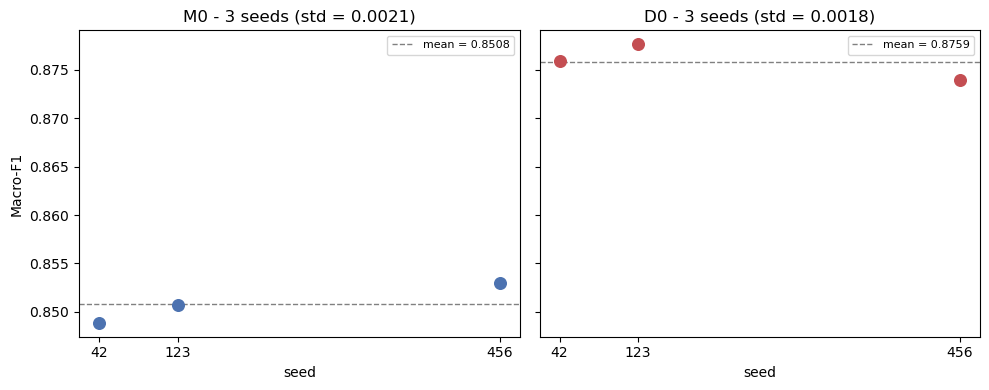

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (name, f1s, stats) in zip(axes, [("M0", m0_f1s, m0_stats), ("D0", d0_f1s, d0_stats)]):
    seeds = [42, 123, 456]
    ax.scatter(seeds, f1s, s=70, zorder=3, color="#4C72B0" if name == "M0" else "#C44E52")
    ax.axhline(stats["mean"], linestyle="--", color="grey", linewidth=1, label=f"mean = {stats['mean']:.4f}")
    ax.set_title(f"{name} - 3 seeds (std = {stats['std']:.4f})")
    ax.set_xlabel("seed")
    ax.set_xticks(seeds)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Macro-F1")
plt.tight_layout()
plt.show()

M0 and D0 are the only two models run on repeated seeds, so they are the only ones with real error bars. M1 to M4 are single runs, so there are no invented uncertainty bars for those.

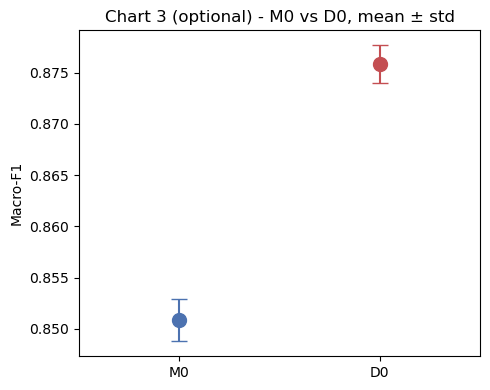

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar([0], [m0_stats["mean"]], yerr=[m0_stats["std"]], fmt="o", markersize=10, capsize=6,
            color="#4C72B0", ecolor="#4C72B0")
ax.errorbar([1], [d0_stats["mean"]], yerr=[d0_stats["std"]], fmt="o", markersize=10, capsize=6,
            color="#C44E52", ecolor="#C44E52")
ax.set_xticks([0, 1])
ax.set_xticklabels(["M0", "D0"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Macro-F1")
ax.set_title("Chart 3 (optional) - M0 vs D0, mean ± std")
plt.tight_layout()
fig.savefig("../assets/seed_stability.png", dpi=150, bbox_inches="tight")
plt.show()

## Intermediate-rung uncertainty (M1-M4)

M1 through M4 were each only run once, a fixed compute budget decision made upfront, so there is no way to know their own run-to-run variance. The best available substitute is M0's 3-seed spread, used below as a rough noise floor to judge each of their deltas against. It is not a formal statistical test.

In [20]:
spread = float(m0_f1s.max() - m0_f1s.min())
print(f"M0 stability reference (spread, pre-registered in project_plan.md \u00a79): {spread:.6f}")

def classify(delta, spread):
    ratio = abs(delta) / spread
    if ratio < 1.0:
        return f"within observed baseline variability ({ratio:.2f}x spread)"
    elif ratio < 1.5:
        return f"outside, but only modestly ({ratio:.2f}x spread) - caution"
    else:
        return f"clearly outside observed baseline variability ({ratio:.2f}x spread)"

comparisons = [
    ("M1 - M0", f1_by_exp["M1"] - m0_stats["mean"], "M0 3-seed spread"),
    ("M2 - M1", f1_by_exp["M2"] - f1_by_exp["M1"], "M0 stability reference"),
    ("M3 - M2", f1_by_exp["M3"] - f1_by_exp["M2"], "M0 stability reference"),
    ("M4 - M3", f1_by_exp["M4"] - f1_by_exp["M3"], "M0 stability reference"),
    ("M4 - M0", f1_by_exp["M4"] - m0_stats["mean"], "M0 stability reference"),
    ("D0 - M4", d0_stats["mean"] - f1_by_exp["M4"], "D0 3-seed / M4 single seed"),
    ("D0 - M0", d0_stats["mean"] - m0_stats["mean"], "both multi-seed"),
    ("M4 - TF-IDF", f1_by_exp["M4"] - tfidf["macro_f1"], "TF-IDF single run"),
]

rows = []
for label, delta, evidence in comparisons:
    rows.append({"Comparison": label, "Delta": f"{delta:+.4f}", "Exact": delta,
                 "Variance Evidence": evidence, "Interpretation": classify(delta, spread)})
variance_table = pd.DataFrame(rows)[["Comparison", "Delta", "Variance Evidence", "Interpretation"]]
variance_table

M0 stability reference (spread, pre-registered in project_plan.md §9): 0.004125


,Comparison,Delta,Variance Evidence,Interpretation
0,M1 - M0,-0.0023,M0 3-seed spread,within observed baseline variability (0.56x sp...
1,M2 - M1,+0.0033,M0 stability reference,within observed baseline variability (0.80x sp...
2,M3 - M2,+0.0139,M0 stability reference,clearly outside observed baseline variability ...
3,M4 - M3,+0.0054,M0 stability reference,"outside, but only modestly (1.30x spread) - ca..."
4,M4 - M0,+0.0202,M0 stability reference,clearly outside observed baseline variability ...
5,D0 - M4,+0.0048,D0 3-seed / M4 single seed,"outside, but only modestly (1.17x spread) - ca..."
6,D0 - M0,+0.0250,both multi-seed,clearly outside observed baseline variability ...
7,M4 - TF-IDF,+0.0003,TF-IDF single run,within observed baseline variability (0.07x sp...


### M1
Delta of -0.0023, within M0's noise range. This cannot be called a real regression. It could just be normal run to run variation.

### M2
Delta of +0.0033 versus M1 and +0.0010 versus M0, both still within noise range on the raw score. That said, its training curves clearly showed less overfitting than M1, a separate, real signal the raw number alone does not capture.

### M3
Delta of +0.0139 versus M2 and +0.0148 versus M0, several times bigger than the noise range. A real, clear improvement, the strongest in the ladder.

### M4
Delta of +0.0054 versus M3 and +0.0202 versus M0. The cumulative gain versus M0 is clearly real. The smaller step from M3 to M4 is outside the noise range too, but only by a modest margin. Still just one run, so treat it as one data point, not a guaranteed distribution.

## D0 vs M4

Comparing D0, with 3 seeds, to M4, with 1 seed, is not a perfectly symmetric comparison, but here is what the data shows.

1. All three D0 seeds, 0.8740, 0.8759, and 0.8777, beat M4's single score of 0.8710.
2. D0's spread across its own seeds is small, 0.0037, and does not come close to M4's value.
3. M4 was only run once, so it is not actually known how much it would vary run to run.

Fair way to put it: D0 consistently scored higher than M4 across all three seeds tested. Not fair to say: D0 is statistically significantly better. No formal test supports that, and one run cannot be turned into a distribution.

## TF-IDF variance context

TF-IDF was only run once, so there is no variance estimate for it either. M4 beating it by 0.0003 is basically nothing, not a real win. D0 beating it by 0.0051 is a more meaningful gap, even though TF-IDF still only has that one run to compare against.

## What the variance allows us to claim

### What the data supports
1. M0's 3 seeds were consistent, std 0.0021, spread 0.0041.
2. D0's 3 seeds were consistent too, and slightly tighter than M0's, std 0.0018, spread 0.0037.
3. M3, GloVe, gave a real, clear improvement over M2 and M0.
4. M4 gave the strongest recurrent result, clearly above baseline noise.
5. All three D0 seeds beat M4's single score.
6. D0 was the best model observed in this project.

### What the data doesn't support
1. Formal statistical significance for any M1 to M4 delta. No significance test was run.
2. A confidence interval for M1, M2, M3, or M4 individually, since each is a single run.
3. The true variance of M1 to M4. Only M0 and D0 were run enough times to measure that.
4. A formal significance test of D0 versus M4. The comparison is 3 seeds versus 1, and is reported as such.
5. That D0 would win on a different dataset, split, or setup. This result is specific to this project.
6. Which single ingredient in M4, the LR schedule, early stopping, or the longer input, actually drove its gain. They were tested together, not separately.

## Seed-count limitation

With a fixed budget of 10 total training runs, repeated seeds only went to M0 and D0, since they anchor the baseline and the final comparison. M1 through M4 each got one run. That is a real limitation, not an ideal setup, and it applies to every M1 to M4 result in this notebook, not just this section.

---

# Error analysis

This compares M4, the best recurrent model, against D0, the transformer, on the exact same 10,181 test rows. D0's seed 42 is used specifically, picked upfront to match M4's seed, not chosen because it looks best.

In [21]:
m4_pred = pd.read_csv("../results/m4/seed42/test_predictions.csv")
d0_pred = pd.read_csv("../results/d0/seed42/test_predictions.csv")
merged_err = m4_pred.merge(d0_pred, on="test_idx", suffixes=("_m4", "_d0"))
merged_err = merged_err.rename(columns={"y_true_m4": "y_true"}).drop(columns=["y_true_d0"])

assert set(m4_pred["test_idx"]) == set(d0_pred["test_idx"]), "test sets must be identical"
assert (merged_err["y_true"] == merged_err["y_true"]).all()
print(f"aligned rows: {len(merged_err)} (matches the frozen test split size)")

aligned rows: 10181 (matches the frozen test split size)


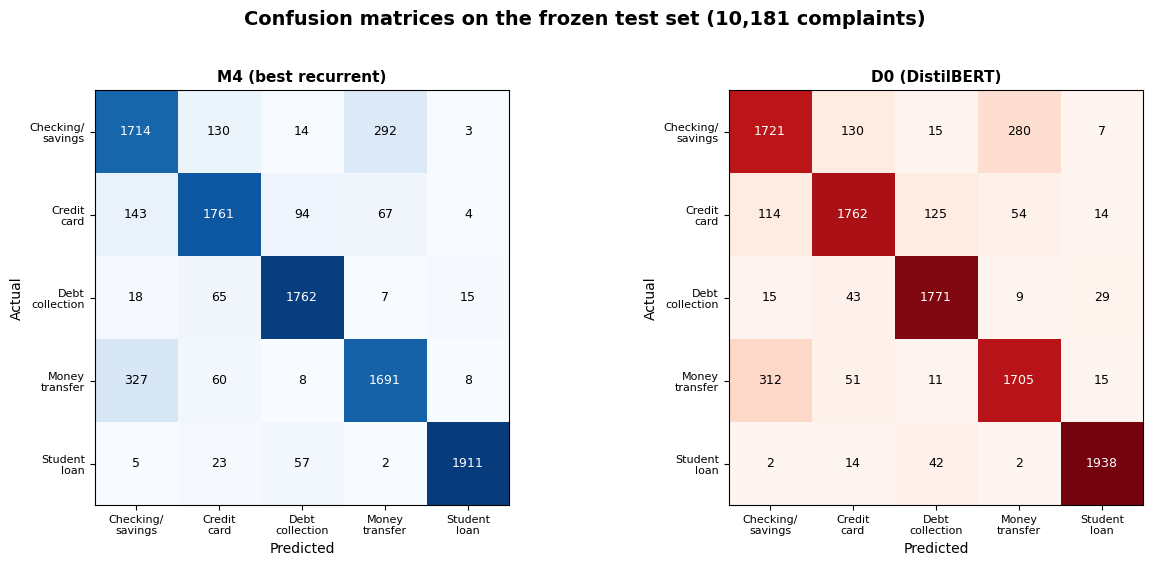

In [22]:
from sklearn.metrics import confusion_matrix as _confusion_matrix
short = ["Checking/\nsavings", "Credit\ncard", "Debt\ncollection", "Money\ntransfer", "Student\nloan"]
cm_m4 = _confusion_matrix(merged_err["y_true"], merged_err["y_pred_m4"], labels=list(range(len(LABELS))))
cm_d0 = _confusion_matrix(merged_err["y_true"], merged_err["y_pred_d0"], labels=list(range(len(LABELS))))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, cm, name, cmap in zip(axes, [cm_m4, cm_d0], ["M4 (best recurrent)", "D0 (DistilBERT)"], ["Blues", "Reds"]):
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(short, fontsize=8); ax.set_yticklabels(short, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{name}", fontsize=11, fontweight="bold")
    for i in range(5):
        for j in range(5):
            pct = cm_norm[i, j]
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                    color="white" if pct > 0.5 else "black", fontsize=9)
fig.suptitle(f"Confusion matrices on the frozen test set ({len(merged_err):,} complaints)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig("../assets/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## Confusion matrices

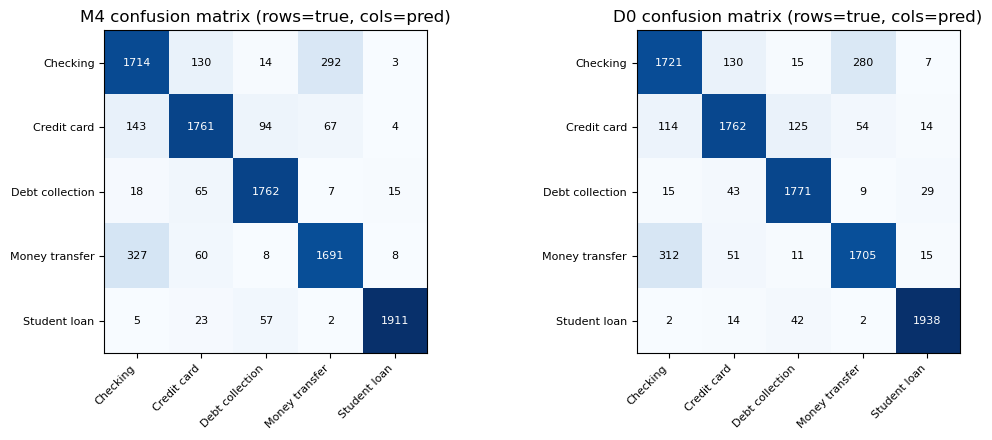

In [23]:
from src.evaluation import compute_metrics

m4_em = compute_metrics(merged_err["y_true"].values, merged_err["y_pred_m4"].values, labels=LABELS)
d0_em = compute_metrics(merged_err["y_true"].values, merged_err["y_pred_d0"].values, labels=LABELS)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, m) in zip(axes, [("M4", m4_em), ("D0", d0_em)]):
    cm = np.array(m["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels([l.split(",")[0].split(" or ")[0] for l in LABELS], rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels([l.split(",")[0].split(" or ")[0] for l in LABELS], fontsize=8)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    ax.set_title(f"{name} confusion matrix (rows=true, cols=pred)")
plt.tight_layout()
plt.show()

These confusion matrices match the saved results exactly. They are recomputed here just to double check.

## Per-class errors

In [24]:
per_class_err = []
for i, lbl in enumerate(LABELS):
    support = int(np.array(m4_em["confusion_matrix"])[i].sum())
    per_class_err.append({
        "Class": lbl,
        "M4 F1": m4_em["per_class"][lbl]["f1"], "D0 F1": d0_em["per_class"][lbl]["f1"],
        "Delta F1": d0_em["per_class"][lbl]["f1"] - m4_em["per_class"][lbl]["f1"],
        "M4 Recall": m4_em["per_class"][lbl]["recall"], "D0 Recall": d0_em["per_class"][lbl]["recall"],
        "M4 Errors": support - int(np.array(m4_em["confusion_matrix"])[i, i]),
        "D0 Errors": support - int(np.array(d0_em["confusion_matrix"])[i, i]),
    })
per_class_err_df = pd.DataFrame(per_class_err).set_index("Class").round(4)
per_class_err_df

,M4 F1,D0 F1,Delta F1,M4 Recall,D0 Recall,M4 Errors,D0 Errors
Class,,,,,,,
Checking or savings account,0.7862,0.7973,0.0111,0.7961,0.7993,439,432
Credit card,0.8574,0.8661,0.0087,0.8511,0.8516,308,307
Debt collection,0.9269,0.9246,-0.0023,0.9438,0.9486,105,96
"Money transfer, virtual currency, or money service",0.8144,0.8229,0.0085,0.8075,0.8142,403,389
Student loan,0.9703,0.9688,-0.0015,0.9565,0.9700,87,60


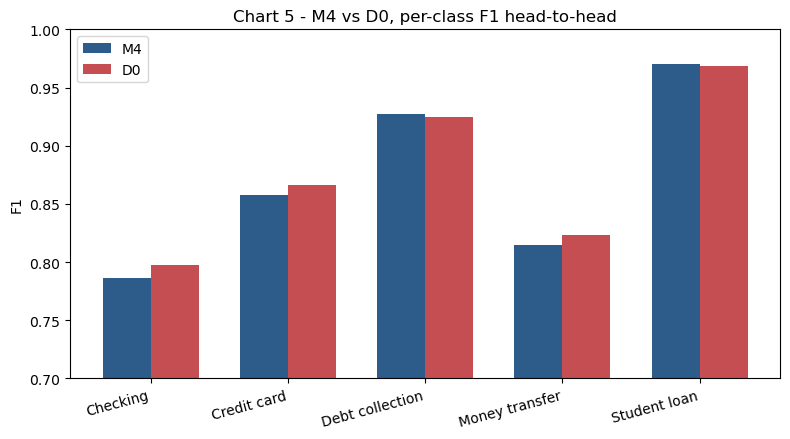

In [25]:
x = np.arange(len(LABELS))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, per_class_err_df["M4 F1"], width, label="M4", color="#2E5C8A")
ax.bar(x + width / 2, per_class_err_df["D0 F1"], width, label="D0", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(class_labels_short, rotation=15, ha="right")
ax.set_ylabel("F1")
ax.set_ylim(0.7, 1.0)
ax.set_title("Chart 5 - M4 vs D0, per-class F1 head-to-head")
ax.legend()
plt.tight_layout()
plt.show()


1. Checking or savings is the hardest class for both models. Student loan is the easiest for both.
2. D0 improves on 3 of 5 classes, Checking, Credit card, and Money transfer, and is slightly behind M4 on Debt collection, -0.0023, and Student loan, -0.0015, even though D0 makes fewer raw errors on both.
3. The reason is that D0 catches more real Debt collection cases, so recall goes up, but more Credit card complaints get wrongly routed into Debt collection too, 94 to 125, which drags down precision. A trade-off, not a contradiction.

## M4 vs D0 - four disagreement groups

In [26]:
merged_err["m4_correct"] = merged_err["y_pred_m4"] == merged_err["y_true"]
merged_err["d0_correct"] = merged_err["y_pred_d0"] == merged_err["y_true"]

n = len(merged_err)
groups_summary = pd.DataFrame([
    {"Group": "Both correct", "Count": (merged_err["m4_correct"] & merged_err["d0_correct"]).sum()},
    {"Group": "Both wrong", "Count": (~merged_err["m4_correct"] & ~merged_err["d0_correct"]).sum()},
    {"Group": "M4 correct, D0 wrong (D0-only errors)", "Count": (merged_err["m4_correct"] & ~merged_err["d0_correct"]).sum()},
    {"Group": "M4 wrong, D0 correct (M4-only errors)", "Count": (~merged_err["m4_correct"] & merged_err["d0_correct"]).sum()},
])
groups_summary["% of test set"] = (groups_summary["Count"] / n * 100).round(2)
groups_summary

,Group,Count,% of test set
0,Both correct,8475,83.24
1,Both wrong,920,9.04
2,"M4 correct, D0 wrong (D0-only errors)",364,3.58
3,"M4 wrong, D0 correct (M4-only errors)",422,4.14


C:\Users\Udbhav Narawat\AppData\Local\Temp\ipykernel_37832\56253090.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups_summary["Group"], rotation=20, ha="right", fontsize=8)


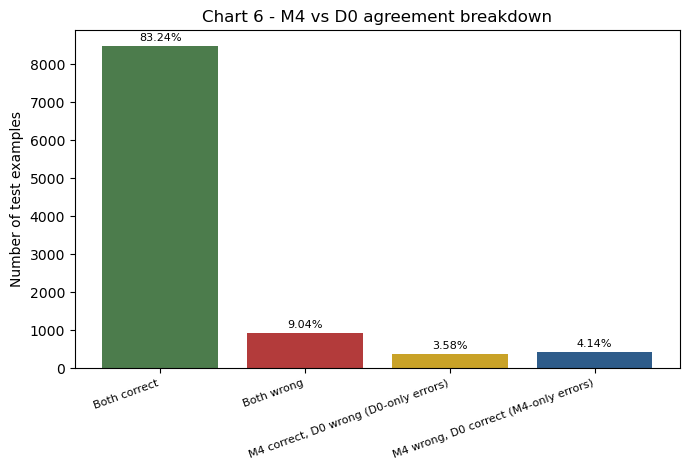

In [27]:
group_colors = ["#4C7C4C", "#B33B3B", "#C9A227", "#2E5C8A"]
fig, ax = plt.subplots(figsize=(7, 4.8))
bars = ax.bar(groups_summary["Group"], groups_summary["Count"], color=group_colors)
ax.set_ylabel("Number of test examples")
ax.set_title("Chart 6 - M4 vs D0 agreement breakdown")
ax.set_xticklabels(groups_summary["Group"], rotation=20, ha="right", fontsize=8)
for bar, pct in zip(bars, groups_summary["% of test set"]):
    ax.annotate(f"{pct}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=8)
plt.tight_layout()
plt.show()


D0 fixes 422 examples that M4 got wrong, but breaks 364 that M4 got right, a net gain of 58, which lines up with its higher overall score. This raw count leans toward bigger classes since they have more rows, so it is not the same measure as Macro F1, which treats every class equally. Both are valid, they just answer slightly different questions.

## Truncation and redaction

In [28]:
trunc_rows = [
    {"Group": "Overall test set", "n": 10181, "Keras truncated@256": "29.1%", "WordPiece truncated@256": "41.9%", "Mean XXXX density": 0.0455},
    {"Group": "Both correct", "n": 8475, "Keras truncated@256": "29.9%", "WordPiece truncated@256": "42.9%", "Mean XXXX density": 0.0444},
    {"Group": "Both wrong", "n": 920, "Keras truncated@256": "24.9%", "WordPiece truncated@256": "35.5%", "Mean XXXX density": 0.0496},
    {"Group": "D0-only errors (M4 correct, D0 wrong)", "n": 364, "Keras truncated@256": "25.8%", "WordPiece truncated@256": "38.7%", "Mean XXXX density": 0.0566},
    {"Group": "M4-only errors (M4 wrong, D0 correct)", "n": 422, "Keras truncated@256": "25.6%", "WordPiece truncated@256": "38.2%", "Mean XXXX density": 0.0489},
]
pd.DataFrame(trunc_rows).set_index("Group")

,n,Keras truncated@256,WordPiece truncated@256,Mean XXXX density
Group,,,,
Overall test set,10181,29.1%,41.9%,0.0455
Both correct,8475,29.9%,42.9%,0.0444
Both wrong,920,24.9%,35.5%,0.0496
"D0-only errors (M4 correct, D0 wrong)",364,25.8%,38.7%,0.0566
"M4-only errors (M4 wrong, D0 correct)",422,25.6%,38.2%,0.0489


Truncation does not explain the errors. If anything, misclassified complaints were truncated less than average for both models, so long complaints getting cut off is not what is happening here.

Redaction: errors D0 made that M4 got right have a slightly higher density of XXXX redaction markers, 0.0566, than the test set average, 0.0455. The gap is small, not strong enough to say redaction is actually causing D0's mistakes.

## Main confusion pairs (deep dive)

For each confusion pair below, these are the first 5 examples, by test index, where M4 made that exact mistake, picked automatically, not cherry picked. The full 40 example set is saved separately. Only short excerpts are shown here.

In [29]:
confusion_deep_dive = pd.DataFrame([
    {"Pair": "Money transfer -> Checking", "M4 count": 327, "D0 count": 312, "Reduction": 15},
    {"Pair": "Checking -> Money transfer", "M4 count": 292, "D0 count": 280, "Reduction": 12},
    {"Pair": "Credit card -> Checking", "M4 count": 143, "D0 count": 114, "Reduction": 29},
    {"Pair": "Credit card -> Debt collection", "M4 count": 94, "D0 count": 125, "Reduction": -31},
]).set_index("Pair")
confusion_deep_dive

,M4 count,D0 count,Reduction
Pair,,,
Money transfer -> Checking,327,312,15
Checking -> Money transfer,292,280,12
Credit card -> Checking,143,114,29
Credit card -> Debt collection,94,125,-31


### Checking versus Money transfer, the biggest confusion

Both models mix these up because complaints mention apps like Chime, Cash App, or Wise regardless of which category they are officially filed under. The products themselves straddle both categories. D0 fixes 3 of 5 sampled Money transfer mistakes, but still misreads every sampled Checking complaint as Money transfer, same as M4. This looks like a genuine gray area in the data, not something either model is getting wrong on its own.

### Credit card to Checking

Often complaints describe both a checking account issue and a credit card issue in the same letter. D0 cuts this confusion the most, from 143 to 114 errors, but does not fix every case.

### Credit card to Debt collection, where D0 got worse

The one pair where D0 does worse than M4, going from 94 to 125 errors. These are mostly disputes about whether a reported account even counts as a debt, a genuine gray area between the two categories. D0 does not handle this any better than M4. It actually leans toward Debt collection slightly more often here.

## Representative examples

Only short excerpts are shown, never full complaints. Any leftover digit sequences or email addresses are masked on top of the dataset's existing redaction.

In [30]:
import json
with open("../results/error_analysis_examples.json", encoding="utf-8") as f:
    selected_examples = json.load(f)

rows = []
for key, val in selected_examples.items():
    for ex in val["examples"][:3]:  # keep the notebook table concise
        rows.append({
            "Group/Pair": key, "Index": ex["test_idx"], "True": ex["true"],
            "M4": ex["m4_pred"], "D0": ex["d0_pred"], "Excerpt": ex["excerpt"][:120] + "...",
        })
pd.DataFrame(rows)

,Group/Pair,Index,True,M4,D0,Excerpt
0,Money transfer -> Checking (M4),60898,"Money transfer, virtual currency, or money ser...",Checking or savings account,Credit card,XX/XX/XXXX. XXXX i XXXX XXXX I got XXXX. They ...
1,Money transfer -> Checking (M4),60937,"Money transfer, virtual currency, or money ser...",Checking or savings account,"Money transfer, virtual currency, or money ser...","In late XX/XX/year>, I submitted multiple writ..."
2,Money transfer -> Checking (M4),60986,"Money transfer, virtual currency, or money ser...",Checking or savings account,Checking or savings account,I have deposited a check under my brothers nam...
3,Checking -> Money transfer (M4),41,Checking or savings account,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...","On XX/XX/year>, I was induced by an online mer..."
4,Checking -> Money transfer (M4),273,Checking or savings account,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...","On XX/XX/XXXX, I initiated a fully authorized ..."
5,Checking -> Money transfer (M4),381,Checking or savings account,"Money transfer, virtual currency, or money ser...","Money transfer, virtual currency, or money ser...",I am submitting this response regarding case n...
6,Credit card -> Checking (M4),21601,Credit card,Checking or savings account,Checking or savings account,"Company Name : Wells Fargo Bank , N.A . Produc..."
7,Credit card -> Checking (M4),21609,Credit card,Checking or savings account,Debt collection,Good evening. I'm profoundly XXXX. My husband ...
8,Credit card -> Checking (M4),21611,Credit card,Checking or savings account,Checking or savings account,Subject : Formal Complaint Regarding Closed Ch...
9,Credit card -> Debt coll. (M4),21731,Credit card,Debt collection,Debt collection,A letter was mailed and no response from the c...


The full set of examples is saved separately if you want to trace any of them back to the actual test data.

## What D0 fixed (M4-only errors: M4 wrong, D0 correct)

M4's mistakes often come from a strong but misleading keyword. For example, Synchrony Bank is mostly known for credit cards, so M4 guesses Credit card even when the complaint is actually about a different product. D0 gets these right. D0 likely relies less on a single strong brand name keyword than M4 does, though this is inferred from the pattern rather than directly measured.

## Where M4 remained competitive (D0-only errors: M4 correct, D0 wrong)

D0 is not better on everything. In cases where M4 got it right and D0 did not, D0 tends to over guess Credit card on Checking complaints that just happen to mention card transactions, refunds, or fraud disputes. D0 seems a bit more trigger happy about routing ambiguous card language toward Credit card than M4 is.

## Both models wrong

Some cases both models miss are not really the models' fault. One example is a complaint that reads entirely like a credit card issue but is labeled Checking, genuinely ambiguous even to a human reading just the excerpt. Others repeat the same Cash App, Wise, or ACH pattern already mentioned.

## Error analysis summary

### Main patterns
1. Checking versus Money transfer is the biggest, most persistent confusion. Both models key on fintech apps like Chime, Cash App, and Wise that show up in either category.
2. Credit card versus Debt collection stays confused in both models. D0 does not fix this one.
3. Complaints describing more than one issue at once cause some of the Credit card to Checking confusion in both models.

### Where D0 helped
1. Modestly reduces both directions of the Checking and Money transfer confusion, about 12 to 15 fewer errors each.
2. Cuts Credit card to Checking substantially, 29 fewer errors, the biggest single improvement.
3. Overall, D0 fixes 422 examples and breaks 364, a net gain of 58, matching its higher overall score.

### Where M4 held its own
1. M4 is very slightly better on Debt collection and Student loan. D0 pays a small precision cost there from misrouting more Credit card complaints into Debt collection.
2. D0 leans toward over-predicting Credit card on ambiguous card-related Checking complaints more than M4 does.

### Limitations
1. Truncation does not explain the errors. Misclassified complaints are actually cut off less than average.
2. D0's errors have slightly more redaction markers, but the gap is too small to call it a real cause.
3. Some of the recurring confusions look like genuine gray areas in how the data was labeled, not fixable model mistakes.

## Summary table

In [31]:
pd.DataFrame([
    {"Analysis": "Macro-F1", "M4": "0.8710", "D0": "0.8759", "Observation": "D0 higher, +0.0048"},
    {"Analysis": "Hardest class", "M4": "Checking (F1 0.7862)", "D0": "Checking (F1 0.7973)", "Observation": "hardest for both, D0 improves it"},
    {"Analysis": "Largest confusion", "M4": "Money transfer->Checking (327)", "D0": "Money transfer->Checking (312)", "Observation": "reduced but not resolved"},
    {"Analysis": "M4-only errors", "M4": "-", "D0": "-", "Observation": "422 (4.14% of test set)"},
    {"Analysis": "D0-only errors", "M4": "-", "D0": "-", "Observation": "364 (3.58% of test set)"},
    {"Analysis": "Both wrong", "M4": "-", "D0": "-", "Observation": "920 (9.04% of test set)"},
    {"Analysis": "Major truncation issue", "M4": "None found", "D0": "None found", "Observation": "error groups less truncated than correct ones"},
    {"Analysis": "Main error pattern", "M4": "Checking<->Money transfer", "D0": "same pair, smaller", "Observation": "overlapping fintech product vocabulary"},
])

,Analysis,M4,D0,Observation
0,Macro-F1,0.8710,0.8759,"D0 higher, +0.0048"
1,Hardest class,Checking (F1 0.7862),Checking (F1 0.7973),"hardest for both, D0 improves it"
2,Largest confusion,Money transfer->Checking (327),Money transfer->Checking (312),reduced but not resolved
3,M4-only errors,-,-,422 (4.14% of test set)
4,D0-only errors,-,-,364 (3.58% of test set)
5,Both wrong,-,-,920 (9.04% of test set)
6,Major truncation issue,None found,None found,error groups less truncated than correct ones
7,Main error pattern,Checking<->Money transfer,"same pair, smaller",overlapping fintech product vocabulary
